In [172]:
import pandas as pd
import numpy as np
import sklearn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, OneHotEncoder

In [173]:
df=pd.read_csv(r'C:\xampp816\htdocs\personal-dev\py-ds\ML\regression\polynomial_regression\salary_dataset_with_extra_features\Salary_Dataset_with_Extra_Features.csv')
df

,Rating,Company Name,Job Title,Salary,Salaries Reported,Location,Employment Status,Job Roles
0,3.8,Sasken,Android Developer,400000,3,Bangalore,Full Time,Android
1,4.5,Advanced Millennium Technologies,Android Developer,400000,3,Bangalore,Full Time,Android
2,4.0,Unacademy,Android Developer,1000000,3,Bangalore,Full Time,Android
3,3.8,SnapBizz Cloudtech,Android Developer,300000,3,Bangalore,Full Time,Android
4,4.4,Appoids Tech Solutions,Android Developer,600000,3,Bangalore,Full Time,Android
...,...,...,...,...,...,...,...,...
22765,4.7,Expert Solutions,Web Developer,200000,1,Bangalore,Full Time,Web
22766,4.0,Nextgen Innovation Labs,Web Developer,300000,1,Bangalore,Full Time,Web
22767,4.1,Fresher,Full Stack Web Developer,192000,13,Bangalore,Full Time,Web
22768,4.1,Accenture,Full Stack Web Developer,300000,7,Bangalore,Full Time,Web


In [174]:
company = df['Company Name'].value_counts()[df['Company Name'].value_counts()>20].index
company

Index(['Tata Consultancy Services', 'Amazon', 'Infosys', 'Accenture',
       'Cognizant Technology Solutions', 'IBM', 'Wipro', 'HCL Technologies',
       'Fresher', 'Capgemini', 'Microsoft', 'Google', 'First Student',
       'Tech Mahindra', 'ABC', 'Oracle', 'Mindtree', 'Freelancer',
       'Dell Technologies', 'DONE by NONE', 'LTI', 'Wipro Technologies',
       'Anonymous', 'Cisco Systems', 'Paytm', 'TCS', 'Deloitte', 'XYZ',
       'Virtusa', 'DXC Technology', 'Flipkart', 'Nones', 'EMPLOYERS',
       'Publicis Sapient', 'Mphasis', 'EPAM Systems',
       'Tata Consultancy Services (North America)', 'Test', 'CGI', 'NTT DATA',
       'XYZ (Turkey)', 'Zoho', 'HCL', 'FIS', 'Expedia Group', 'OYO', 'Verizon',
       'Anonymous Content', 'YES', 'Ola', 'Honeywell', 'J.P. Morgan',
       'BNY Mellon', 'Bharti Airtel', 'ITC Infotech', 'Fiserv',
       'Persistent Systems', 'Jio', 'Zomato', 'GlobalLogic', 'Mastercard',
       'PayPal', 'Fresherworld.com', 'Freshworks', 'Samsung Electronics',
    

In [175]:
df = df[df['Company Name'].apply(lambda x:x in company)]

In [176]:
df.duplicated().sum()

np.int64(0)

In [177]:
df.isna().sum()

Rating               0
Company Name         0
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64

In [178]:
df.dropna(inplace=True)
df.isna().sum()

C:\Users\rijok\AppData\Local\Temp\ipykernel_19108\3486782518.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.dropna(inplace=True)


Rating               0
Company Name         0
Job Title            0
Salary               0
Salaries Reported    0
Location             0
Employment Status    0
Job Roles            0
dtype: int64

In [179]:
df.dtypes

Rating               float64
Company Name          object
Job Title             object
Salary                 int64
Salaries Reported      int64
Location              object
Employment Status     object
Job Roles             object
dtype: object

In [180]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3752 entries, 5 to 22768
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Rating             3752 non-null   float64
 1   Company Name       3752 non-null   object 
 2   Job Title          3752 non-null   object 
 3   Salary             3752 non-null   int64  
 4   Salaries Reported  3752 non-null   int64  
 5   Location           3752 non-null   object 
 6   Employment Status  3752 non-null   object 
 7   Job Roles          3752 non-null   object 
dtypes: float64(1), int64(2), object(5)
memory usage: 263.8+ KB


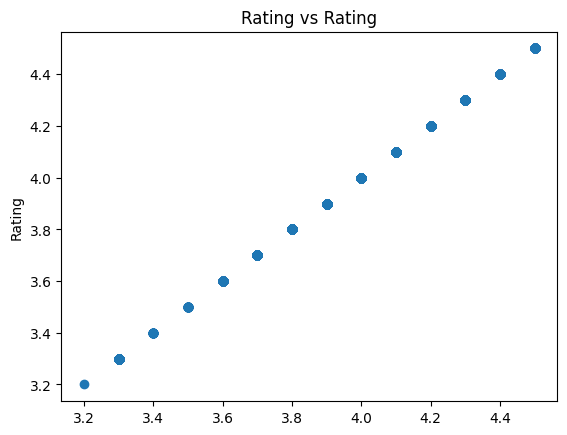

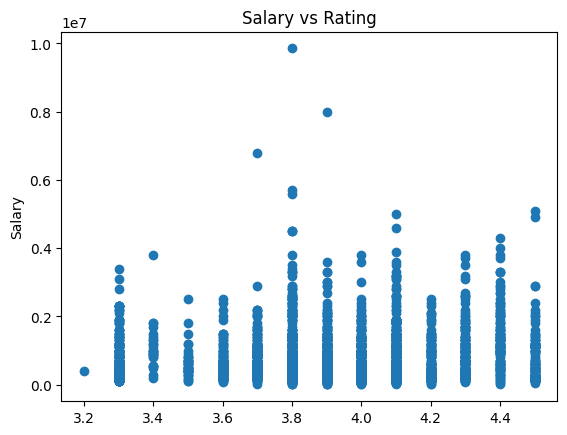

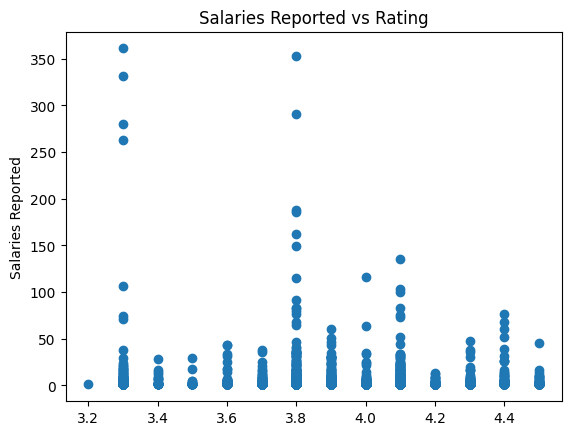

In [181]:
for i in df:
    if df[i].dtype=='int64' or df[i].dtype=='float':
        plt.scatter(df['Rating'], df[i])
        plt.title(f"{i} vs Rating")
        plt.ylabel(i)
        plt.show()

<Axes: >

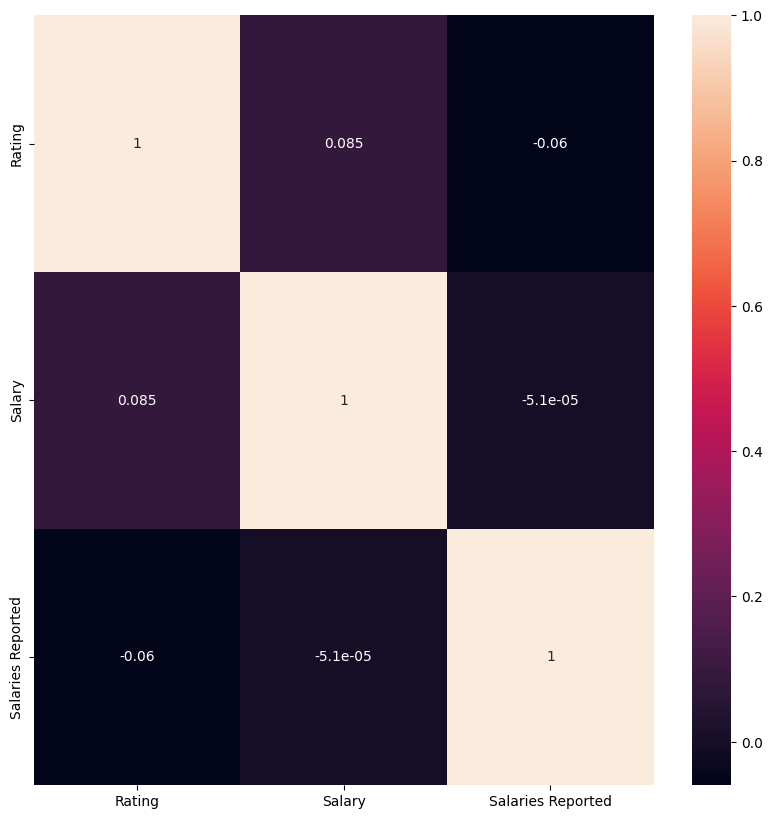

In [182]:
plt.figure(figsize=(10,10))
sns.heatmap(df.corr(numeric_only=True), annot=True)

In [183]:
onehot_cols = ['Location', 'Employment Status', 'Job Roles'];
for i in onehot_cols:
    onehot=OneHotEncoder(sparse_output=False, drop='first')
    res=onehot.fit_transform(df[[i]])
    res=pd.DataFrame(res, columns=onehot.get_feature_names_out())
    df.drop(columns=[i], inplace=True)
    df.reset_index(drop=True, inplace=True)
    df = df.join(res)

C:\Users\rijok\AppData\Local\Temp\ipykernel_19108\2263938117.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df.drop(columns=[i], inplace=True)


In [184]:
df=df.drop(columns=['Company Name', 'Job Title'])
df

,Rating,Salary,Salaries Reported,Location_Chennai,Location_Hyderabad,Location_Jaipur,Location_Kerala,Location_Kolkata,Location_Madhya Pradesh,Location_Mumbai,...,Job Roles_Backend,Job Roles_Database,Job Roles_Frontend,Job Roles_IOS,Job Roles_Java,Job Roles_Mobile,Job Roles_Python,Job Roles_SDE,Job Roles_Testing,Job Roles_Web
0,4.2,100000,3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,4.0,1000000,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,4.1,408000,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,3.6,500000,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,4.1,540000,2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3747,3.3,372000,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3748,4.0,576000,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3749,4.1,444000,1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3750,4.1,192000,13,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [185]:
x=df.drop(columns='Rating')
y=df['Rating']

In [186]:
from sklearn.preprocessing import MinMaxScaler
minmax=MinMaxScaler()
x_scaled = minmax.fit_transform(x)

In [187]:
from sklearn.preprocessing import PolynomialFeatures
poly=PolynomialFeatures(degree=2)
x_poly=poly.fit_transform(x_scaled)

In [188]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x_poly, y, test_size=0.3, random_state=5)

In [189]:
from sklearn.linear_model import LinearRegression
poly_model=LinearRegression()
poly_model.fit(x_train, y_train)

LinearRegression()

In [190]:
y_pred = poly_model.predict(x_test)

In [191]:
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error
print("R squared Value", r2_score(y_test, y_pred))
print("Mean Absolute Error", mean_absolute_error(y_test, y_pred))
print("Root Mean Squared Value", root_mean_squared_error(y_test, y_pred))

R squared Value -0.40563206831569687
Mean Absolute Error 0.21942028531457847
Root Mean Squared Value 0.3261570776124518


In [192]:
from sklearn.model_selection import cross_val_score
print('Polinomial Regression : ', cross_val_score(LinearRegression(),x_poly, y, cv=10).mean()*100)

Polinomial Regression :  -12.292612625545264


In [193]:
from sklearn.tree import DecisionTreeRegressor

dtr_model = DecisionTreeRegressor()
dtr_model.fit(x_train, y_train)

DecisionTreeRegressor()

In [194]:
dtr_model.score(x_train, y_train)

0.721919594974623

In [195]:
dtr_model.score(x_test, y_test)

-0.7555460129538045